# Glutamate sequence QC

Inspect facilitation/adaptation metrics derived from repeated image sequences.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

Loaded 56 session assets


In [37]:
%matplotlib notebook

In [ ]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

In [7]:
analysis_dir = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803121\2025-11-01_803121\analysis') / 'derived' / 'glutamate' /'glutamate_analysis'
sequence_per_image = pd.read_parquet(analysis_dir / 'sequence_per_image_table.parquet')
sequence_summary = pd.read_parquet(analysis_dir / 'sequence_summary_table.parquet')
sequence_summary

,session_id,subject_id,dmd,synapse_id,n_images_with_sequences,median_seq_slope,median_adaptation_index,median_r0,median_rlast,median_rterminal,median_terminal_minus_last,median_early_minus_late,seq_p,sequence_class,seq_q
0,803121_2025-11-01_19-00-21,803121,DMD1,DMD1_syn0000,7,-37.380773,-0.054981,1429.336716,2235.669611,1636.768138,-722.098456,601.386686,0.218750,stable,0.450368
1,803121_2025-11-01_19-00-21,803121,DMD1,DMD1_syn0001,7,-86.422404,-0.059954,3167.008117,2167.417780,5413.746134,4027.862129,2331.244226,0.218750,stable,0.450368
2,803121_2025-11-01_19-00-21,803121,DMD1,DMD1_syn0002,7,-37.077513,0.434892,2010.150386,2166.858883,2643.288324,-1690.664027,517.157446,0.218750,stable,0.450368
3,803121_2025-11-01_19-00-21,803121,DMD1,DMD1_syn0004,7,-27.033329,1.000000,1557.865565,-1327.141147,1720.544844,2610.453164,1304.688751,0.218750,stable,0.450368
4,803121_2025-11-01_19-00-21,803121,DMD1,DMD1_syn0006,7,-21.772863,0.241804,1157.781524,548.413953,1761.799974,1213.386021,380.016334,0.687500,stable,0.925481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0095,7,-33.231407,1.000000,1153.746694,-1838.816468,1403.591919,3242.408387,-205.927314,0.109375,stable,0.431743
101,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0096,7,-5.192634,0.857865,370.613633,-3539.770891,1355.922848,4895.693739,2010.569731,0.812500,stable,0.958567
102,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0098,7,-37.002884,0.666518,5621.393326,1069.662508,8700.913998,7671.648067,2312.925590,0.156250,stable,0.431743
103,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0099,7,-30.834866,-0.189897,4150.546760,3559.799733,4063.092552,1004.304766,-1602.546012,1.000000,stable,1.000000


In [8]:
display(
    sequence_summary.groupby(['dmd', 'sequence_class']).size().rename('n').reset_index()
)

,dmd,sequence_class,n
0,DMD1,stable,22
1,DMD2,stable,83


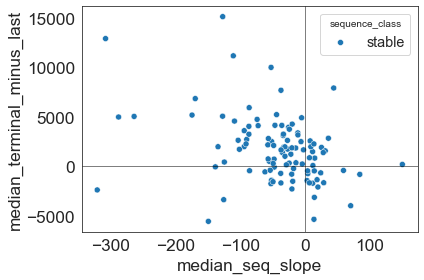

In [9]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=sequence_summary, x='median_seq_slope', y='median_terminal_minus_last', hue='sequence_class')
plt.axvline(0, color='k', lw=1, alpha=0.5)
plt.axhline(0, color='k', lw=1, alpha=0.5)
plt.tight_layout()

<IPython.core.display.Javascript object>


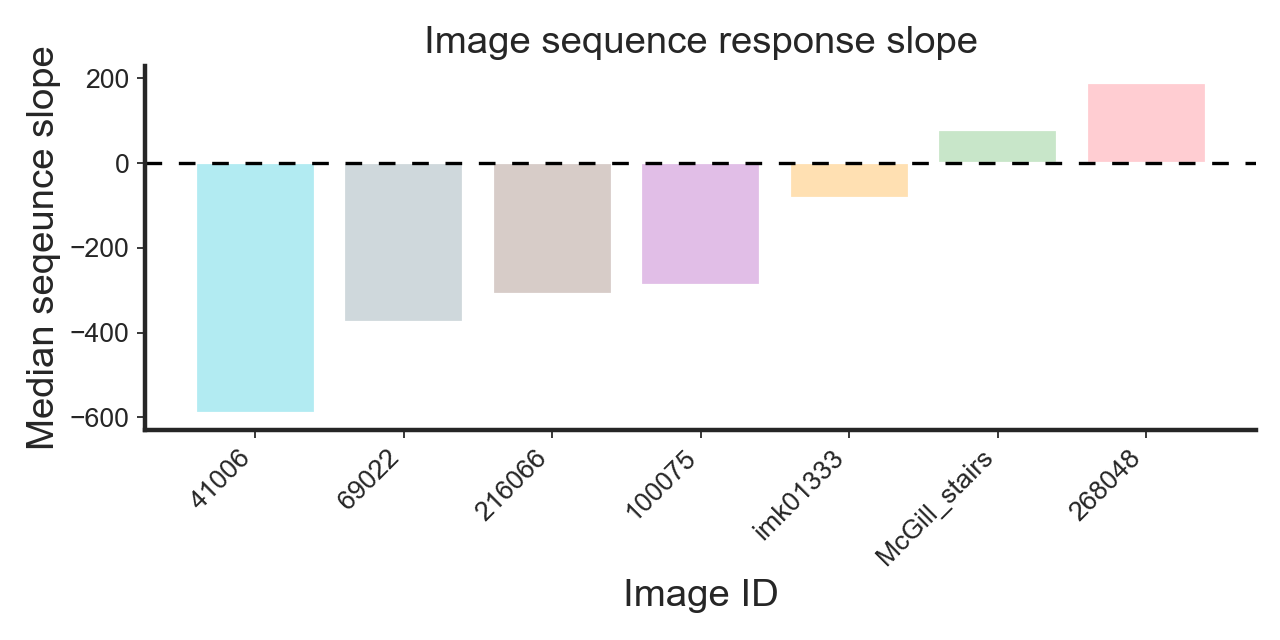

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_positions,n_sequences,r0,rlast,rterminal,terminal_minus_last,early_mean,late_mean,early_minus_late,adaptation_index,sequence_slope
515,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\41006.tiff,41006,35,33,34764.907677,5110.295125,2918.043633,-2192.251492,30040.727083,5744.123996,24296.603087,0.743686,-590.577329
517,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\69022.tiff,69022,15,32,10749.491775,10938.423040,15910.043373,4971.620333,8110.561063,15625.206411,-7514.645348,-0.008711,-375.315445
516,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\216066.tiff,216066,20,32,11909.093597,13868.538858,9147.355962,-4721.182896,9436.905241,8640.417014,796.488227,-0.076013,-309.363134
512,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\100075.tiff,100075,38,34,11645.429567,3405.852724,13316.844728,9910.992004,11476.769120,2361.890982,9114.878138,0.547434,-287.257079
513,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\imk01333.tiff,imk01333,47,33,8503.779345,-2924.357340,11755.751578,14680.108918,7927.418521,-1258.475865,9185.894386,1.000000,-81.104504
511,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\McGill_stairs.tiff,McGill_stairs,19,33,-532.788111,-5138.901404,11099.855076,16238.756480,-3214.922163,-4810.433696,1595.511533,0.812124,77.448468
514,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\268048.tiff,268048,31,33,6840.094581,18116.572651,18621.286660,504.714009,3630.209808,10943.532441,-7313.322634,-0.451842,190.116512


In [141]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

sub = (
    sequence_per_image
    .query('dmd == @example.dmd and synapse_id == @example.synapse_id')
    .sort_values('sequence_slope')
    .copy()
)

stim_order = sub['stimulus_label'].tolist()
palette = [colors[i % len(colors)] for i in range(len(sub))]

# pick the right column name here
# yerr = sub['sem_seq_slope'].to_numpy()   # or sub['std_seq_slope']

ax.bar(
    np.arange(len(sub)),
    sub['sequence_slope'].to_numpy(),
    color=palette,
#     edgecolor='k',
    linewidth=1,
#     yerr=yerr,
    capsize=4,
    error_kw={'linewidth': 1.5, 'color': 'k'}
)

ax.set_xticks(np.arange(len(sub)))
ax.set_xticklabels(stim_order, rotation=45, ha='right')

ax.set_xlabel('Image ID')
ax.set_ylabel('Median seqeunce slope')

ax.axhline(0,color='k',dashes=[5,5])

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
ax.set_title('Image sequence response slope')
plt.tight_layout()
sub.head(20)

In [127]:
sequence_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803121\2025-11-01_803121\analysis\derived\glutamate\glutamate_sequence_df.npz"

In [128]:
seq_df = np.load(sequence_path,allow_pickle=True)['data'][0]

In [129]:
keys = list(seq_df['DMD2']['image_identity'].keys())
print(keys)

['stimuli\\images_B\\McGill_stairs.tiff', 'stimuli\\images_B\\100075.tiff', 'stimuli\\images_B\\imk01333.tiff', 'stimuli\\images_B\\268048.tiff', 'stimuli\\images_B\\41006.tiff', 'stimuli\\images_B\\216066.tiff', 'stimuli\\images_B\\69022.tiff']


In [130]:
mean_im1_resps = seq_df['DMD2']['image_identity'][keys[2]]['repeated']['mean'].transpose(1,0,2)[65][:8]
shape = mean_im1_resps.shape
concat_traces = mean_im1_resps.reshape(shape[0]*shape[1])

<IPython.core.display.Javascript object>


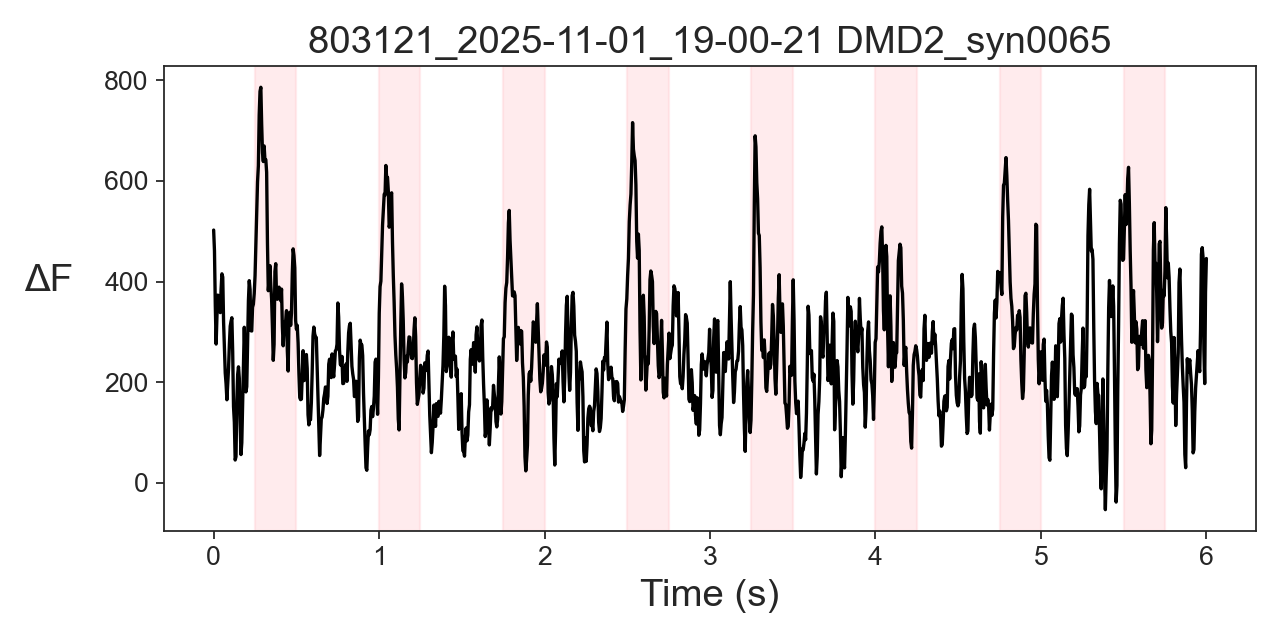

In [134]:
fig,ax=plt.subplots(figsize=(8,4))
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
mean = concat_traces
time = np.linspace(0,len(mean)/200,len(mean))
ax.plot(time,mean,color='k')

ax.set_xlabel('Time (s)')
ax.set_ylabel('\u0394F',rotation=0,labelpad=25)
fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

n_flashes = shape[0]  # change as needed

for i in range(n_flashes):
    start = flash_start + i * cycle_dur
    end = start + flash_dur
    ax.axvspan(start, end, alpha=0.4,color=colors[-2])
ax.set_title(f'{sub["session_id"].unique()[0]} {sub["synapse_id"].unique()[0]}')
fig.tight_layout()

In [123]:
sub

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_positions,n_sequences,r0,rlast,rterminal,terminal_minus_last,early_mean,late_mean,early_minus_late,adaptation_index,sequence_slope
515,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\41006.tiff,41006,35,33,34764.907677,5110.295125,2918.043633,-2192.251492,30040.727083,5744.123996,24296.603087,0.743686,-590.577329
517,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\69022.tiff,69022,15,32,10749.491775,10938.423040,15910.043373,4971.620333,8110.561063,15625.206411,-7514.645348,-0.008711,-375.315445
516,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\216066.tiff,216066,20,32,11909.093597,13868.538858,9147.355962,-4721.182896,9436.905241,8640.417014,796.488227,-0.076013,-309.363134
512,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\100075.tiff,100075,38,34,11645.429567,3405.852724,13316.844728,9910.992004,11476.769120,2361.890982,9114.878138,0.547434,-287.257079
513,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\imk01333.tiff,imk01333,47,33,8503.779345,-2924.357340,11755.751578,14680.108918,7927.418521,-1258.475865,9185.894386,1.000000,-81.104504
511,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\McGill_stairs.tiff,McGill_stairs,19,33,-532.788111,-5138.901404,11099.855076,16238.756480,-3214.922163,-4810.433696,1595.511533,0.812124,77.448468
514,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0065,stimuli\images_B\268048.tiff,268048,31,33,6840.094581,18116.572651,18621.286660,504.714009,3630.209808,10943.532441,-7313.322634,-0.451842,190.116512
